# Native BPGD On `bicycle_bivariate_144_12_12` Memory-X

This notebook runs five native decoders on the `bicycle_bivariate_144_12_12_memory_X` test circuits:

1. Plain `msl-bp` with `max_iter = 100`
2. Damped `msl-bp` with `c_damp = 0.5` and `max_iter = 100`
3. Native `BPGD` with `pre_iter = 50`, `r_low = 5`, `t_low = t_high = 10`, `r_high = 0`, and `c_damp = 0.5`
4. Native `BPGD` with the same settings, plus `initial_decimation_percentage = 0.98`, `r_high = max`, and `c_damp = 0.5`
5. Native `BPGD` with the same settings, plus `initial_decimation_percentage = 0.9`, `r_high = max`, and `c_damp = 0.5`

All BPGD decoders use `alpha = 1.0` and no fallback.

The decoder run cells below are cumulative: after each cell, the plot includes all decoders that have been run so far.

In [1]:
import multiprocessing
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import sinter
import stim
from IPython.display import display

from relay_bp.stim import SinterDecoder_BPGD, SinterDecoder_DampedBP, SinterDecoder_MSLBP
from relay_bp.stim.sinter.utils import write_stats


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "tests" / "testdata" / "bicycle_bivariate").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find repo root containing tests/testdata/bicycle_bivariate "
        f"starting from {start}."
    )


repo_root = find_repo_root(Path.cwd().resolve())
circuits_dir = repo_root / "tests" / "testdata" / "bicycle_bivariate"
data_dir = repo_root / "examples" / "notebook_data" / "bicycle_bivariate_144_12_12_native_bpgd"
data_dir.mkdir(parents=True, exist_ok=True)

print("repo_root =", repo_root)
print("circuits_dir =", circuits_dir)
print("data_dir =", data_dir)


repo_root = C:\Users\User\Documents\projects-git\relay_mother_folder\relay
circuits_dir = C:\Users\User\Documents\projects-git\relay_mother_folder\relay\tests\testdata\bicycle_bivariate
data_dir = C:\Users\User\Documents\projects-git\relay_mother_folder\relay\examples\notebook_data\bicycle_bivariate_144_12_12_native_bpgd


In [2]:
selected_p_values = [0.001, 0.002, 0.003, 0.004, 0.005]
shots_by_p = {
    0.001: 100_000,
    0.002: 10_000,
    0.003: 1_000,
    0.004: 500,
    0.005: 500,
}

alpha = 1.0
baseline_max_iter = 100
c_damp = 0.5

pre_iter = 50
r_low = 5
t_low = 10
t_high = 10
r_high_max = 1_000_000  # Effectively "max"; native BPGD caps this to the available variable count.

num_workers = max(1, multiprocessing.cpu_count() - 1)
print_progress = True
load_data = True
save_data = True
reset_data = False

save_stem = "bicycle_bivariate_144_12_12_native_bpgd"
resume_csv = data_dir / f"{save_stem}_resume.csv"
summary_csv = data_dir / f"{save_stem}_summary.csv"
flat_summary_csv = data_dir / f"{save_stem}_flat_summary.csv"

if reset_data:
    for path in [resume_csv, summary_csv, flat_summary_csv]:
        if path.exists():
            path.unlink()

print("resume_csv =", resume_csv)
print("summary_csv =", summary_csv)
print("flat_summary_csv =", flat_summary_csv)


resume_csv = C:\Users\User\Documents\projects-git\relay_mother_folder\relay\examples\notebook_data\bicycle_bivariate_144_12_12_native_bpgd\bicycle_bivariate_144_12_12_native_bpgd_resume.csv
summary_csv = C:\Users\User\Documents\projects-git\relay_mother_folder\relay\examples\notebook_data\bicycle_bivariate_144_12_12_native_bpgd\bicycle_bivariate_144_12_12_native_bpgd_summary.csv
flat_summary_csv = C:\Users\User\Documents\projects-git\relay_mother_folder\relay\examples\notebook_data\bicycle_bivariate_144_12_12_native_bpgd\bicycle_bivariate_144_12_12_native_bpgd_flat_summary.csv


In [ ]:
def parse_name_metadata(path: Path) -> dict:
    metadata = {"stim_path": str(path)}
    for part in path.stem.split(","):
        if "=" not in part:
            continue
        key, value = part.split("=", 1)
        metadata[key] = value
    if "error_rate" in metadata:
        metadata["p"] = float(metadata["error_rate"])
    return metadata


def find_circuits(circuits_dir: Path, selected_p_values: list[float]) -> list[Path]:
    wanted = {str(p) for p in selected_p_values}
    matched = []
    for path in sorted(circuits_dir.glob("circuit=bicycle_bivariate_144_12_12_memory_X,*.stim")):
        metadata = parse_name_metadata(path)
        if metadata.get("error_rate") in wanted:
            matched.append(path)

    matched = sorted(matched, key=lambda path: parse_name_metadata(path)["p"])
    found = {parse_name_metadata(path)["error_rate"] for path in matched}
    missing = sorted(float(p) for p in (wanted - found))
    if missing:
        raise FileNotFoundError(
            f"Missing 144_12_12 memory_X circuits for p values: {missing} in {circuits_dir}."
        )
    return matched


def select_num_shots(p: float) -> int:
    key = round(float(p), 3)
    if key not in shots_by_p:
        raise KeyError(f"No shot budget configured for p={p}.")
    return shots_by_p[key]


def build_tasks(circuit_paths: list[Path]) -> list[sinter.Task]:
    tasks = []
    for circuit_path in circuit_paths:
        circuit = stim.Circuit.from_file(circuit_path)
        dem = circuit.detector_error_model()
        metadata = parse_name_metadata(circuit_path)
        tasks.append(
            sinter.Task(
                circuit=circuit,
                detector_error_model=dem,
                json_metadata=metadata,
                collection_options=sinter.CollectionOptions(
                    max_shots=select_num_shots(metadata["p"])
                ),
            )
        )
    return tasks


matched_circuits = find_circuits(circuits_dir, selected_p_values)
matched_metadata_df = pd.DataFrame([parse_name_metadata(path) for path in matched_circuits])
tasks = build_tasks(matched_circuits)

display(
    matched_metadata_df[["circuit", "p", "basis", "noise_model", "distance", "rounds", "stim_path"]]
    .sort_values("p")
    .reset_index(drop=True)
)
print("Number of tasks =", len(tasks))


,circuit,p,basis,noise_model,distance,rounds,stim_path
0,bicycle_bivariate_144_12_12_memory_X,0.001,CX,uniform_circuit,12,12,C:\Users\User\Documents\projects-git\relay_mot...
1,bicycle_bivariate_144_12_12_memory_X,0.002,CX,uniform_circuit,12,12,C:\Users\User\Documents\projects-git\relay_mot...
2,bicycle_bivariate_144_12_12_memory_X,0.003,CX,uniform_circuit,12,12,C:\Users\User\Documents\projects-git\relay_mot...
3,bicycle_bivariate_144_12_12_memory_X,0.004,CX,uniform_circuit,12,12,C:\Users\User\Documents\projects-git\relay_mot...
4,bicycle_bivariate_144_12_12_memory_X,0.005,CX,uniform_circuit,12,12,C:\Users\User\Documents\projects-git\relay_mot...


Number of tasks = 5


In [4]:
custom_decoders = {
    "msl-bp": SinterDecoder_MSLBP(
        max_iter=baseline_max_iter,
        alpha=alpha,
        decoder_label="msl-bp",
    ),
    "msl-bp-damp0p5": SinterDecoder_DampedBP(
        max_iter=baseline_max_iter,
        alpha=alpha,
        c_damp=c_damp,
        decoder_label="msl-bp-damp0p5",
    ),
    "bpgd-low-only": SinterDecoder_BPGD(
        pre_iter=pre_iter,
        initial_decimation_percentage=0.0,
        r_low=r_low,
        t_low=t_low,
        r_high=0,
        t_high=t_high,
        alpha=alpha,
        c_damp=c_damp,
        fallback_kind="none",
        decoder_label="bpgd-low-only",
    ),
    "bpgd-high-init0p98": SinterDecoder_BPGD(
        pre_iter=pre_iter,
        initial_decimation_percentage=0.98,
        r_low=r_low,
        t_low=t_low,
        r_high=r_high_max,
        t_high=t_high,
        alpha=alpha,
        c_damp=c_damp,
        fallback_kind="none",
        decoder_label="bpgd-high-init0p98",
    ),
    "bpgd-high-init0p9": SinterDecoder_BPGD(
        pre_iter=pre_iter,
        initial_decimation_percentage=0.9,
        r_low=r_low,
        t_low=t_low,
        r_high=r_high_max,
        t_high=t_high,
        alpha=alpha,
        c_damp=c_damp,
        fallback_kind="none",
        decoder_label="bpgd-high-init0p9",
    ),
    "msl-bp-damp0p5_1k": SinterDecoder_DampedBP(
        max_iter=1000,
        alpha=alpha,
        c_damp=c_damp,
        decoder_label="msl-bp-damp0p5_1k",
    ),
    "msl-bp_10k": SinterDecoder_MSLBP(
        max_iter=10000,
        alpha=alpha,
        decoder_label="msl-bp_10k",
    ),
}

decoder_sequence = list(custom_decoders.keys())
decoder_config_df = pd.DataFrame(
    [
        {
            "decoder": "msl-bp",
            "kind": "native msl-bp",
            "alpha": alpha,
            "c_damp": None,
            "max_iter": baseline_max_iter,
            "pre_iter": None,
            "r_low": None,
            "t_low": None,
            "r_high": None,
            "t_high": None,
            "initial_decimation_percentage": None,
        },
        {
            "decoder": "msl-bp-damp0p5",
            "kind": "native damped msl-bp",
            "alpha": alpha,
            "c_damp": c_damp,
            "max_iter": baseline_max_iter,
            "pre_iter": None,
            "r_low": None,
            "t_low": None,
            "r_high": None,
            "t_high": None,
            "initial_decimation_percentage": None,
        },
        {
            "decoder": "bpgd-low-only",
            "kind": "native BPGD",
            "alpha": alpha,
            "c_damp": c_damp,
            "max_iter": None,
            "pre_iter": pre_iter,
            "r_low": r_low,
            "t_low": t_low,
            "r_high": 0,
            "t_high": t_high,
            "initial_decimation_percentage": 0.0,
        },
        {
            "decoder": "bpgd-high-init0p98",
            "kind": "native BPGD",
            "alpha": alpha,
            "c_damp": c_damp,
            "max_iter": None,
            "pre_iter": pre_iter,
            "r_low": r_low,
            "t_low": t_low,
            "r_high": f"max ({r_high_max} sentinel)",
            "t_high": t_high,
            "initial_decimation_percentage": 0.98,
        },
        {
            "decoder": "bpgd-high-init0p9",
            "kind": "native BPGD",
            "alpha": alpha,
            "c_damp": c_damp,
            "max_iter": None,
            "pre_iter": pre_iter,
            "r_low": r_low,
            "t_low": t_low,
            "r_high": f"max ({r_high_max} sentinel)",
            "t_high": t_high,
            "initial_decimation_percentage": 0.9,
        },
    ]
)

display(decoder_config_df)


,decoder,kind,alpha,c_damp,max_iter,pre_iter,r_low,t_low,r_high,t_high,initial_decimation_percentage
0,msl-bp,native msl-bp,1.0,NaN,100.0,NaN,NaN,NaN,None,NaN,NaN
1,msl-bp-damp0p5,native damped msl-bp,1.0,0.5,100.0,NaN,NaN,NaN,None,NaN,NaN
2,bpgd-low-only,native BPGD,1.0,0.5,NaN,50.0,5.0,10.0,0,10.0,0.00
3,bpgd-high-init0p98,native BPGD,1.0,0.5,NaN,50.0,5.0,10.0,max (1000000 sentinel),10.0,0.98
4,bpgd-high-init0p9,native BPGD,1.0,0.5,NaN,50.0,5.0,10.0,max (1000000 sentinel),10.0,0.90


In [ ]:
def samples_to_df(samples: list[sinter.TaskStats]) -> pd.DataFrame:
    rows = []
    for stat in samples:
        circuit_name = stat.json_metadata["circuit"]
        rows.append(
            {
                "decoder": stat.decoder,
                "circuit": circuit_name,
                "memory": circuit_name.rsplit("_", 1)[-1],
                "p": float(stat.json_metadata["p"]),
                "shots": stat.shots,
                "errors": stat.errors,
                "seconds": stat.seconds,
            }
        )

    if not rows:
        return pd.DataFrame(
            columns=["decoder", "circuit", "memory", "p", "shots", "errors", "seconds", "ler", "stderr"]
        )

    df = pd.DataFrame(rows)
    summary_df = (
        df.groupby(["decoder", "circuit", "memory", "p"], as_index=False)
        .agg(shots=("shots", "sum"), errors=("errors", "sum"), seconds=("seconds", "sum"))
        .sort_values(["decoder", "p"])
        .reset_index(drop=True)
    )
    summary_df["ler"] = summary_df["errors"] / summary_df["shots"]
    summary_df["stderr"] = ((summary_df["ler"] * (1.0 - summary_df["ler"]) / summary_df["shots"]).clip(lower=0.0)) ** 0.5
    return summary_df


def plot_summary(summary_df: pd.DataFrame, title: str) -> None:
    if summary_df.empty:
        print("No samples available to plot.")
        return

    fig, ax = plt.subplots(figsize=(9, 5))
    available = [name for name in decoder_sequence if name in set(summary_df["decoder"])]
    for decoder_name in available:
        group = summary_df[summary_df["decoder"] == decoder_name].sort_values("p")
        ax.plot(group["p"], group["ler"], marker="o", linewidth=1.8, label=decoder_name)

    ax.set_title(title)
    ax.set_xlabel("physical error rate p")
    ax.set_ylabel("logical error rate")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    plt.show()


def run_decoder(decoder_name: str, *, plot_title: str | None = None) -> tuple[list[sinter.TaskStats], pd.DataFrame]:
    if decoder_name not in custom_decoders:
        raise KeyError(f"Unknown decoder: {decoder_name}")

    save_resume_path = resume_csv if save_data else None
    existing = []
    if load_data and resume_csv.exists() and save_resume_path is None:
        existing = [resume_csv]

    samples = sinter.collect(
        tasks=tasks,
        decoders=[decoder_name],
        custom_decoders={decoder_name: custom_decoders[decoder_name]},
        num_workers=num_workers,
        print_progress=print_progress,
        existing_data_filepaths=existing,
        save_resume_filepath=save_resume_path,
    )

    if save_data:
        write_stats(samples, summary_csv)

    summary_df = samples_to_df(samples)
    if save_data:
        summary_df.to_csv(flat_summary_csv, index=False)

    display(
        summary_df[["decoder", "p", "shots", "errors", "ler", "seconds"]]
        .sort_values(["decoder", "p"])
        .reset_index(drop=True)
    )
    plot_summary(summary_df, plot_title or f"Cumulative logical error rate after {decoder_name}")

    print("resume_csv =", resume_csv)
    print("summary_csv =", summary_csv)
    print("flat_summary_csv =", flat_summary_csv)
    return samples, summary_df


: 

## Decoder 1: Plain `msl-bp`

In [ ]:
samples, summary_df = run_decoder(
    "msl-bp",
    plot_title="Cumulative logical error rate after msl-bp",
)


Starting 7 workers...
9 tasks left:
  workers decoder eta shots_taken errors_seen json_metadata                                                                                                                                                                                                                                                                                                                                                                                                              
        1  msl-bp   ?           0           0 stim_path=C:\Users\User\Documents\projects-git\relay_mother_folder\relay\tests\testdata\bicycle_bivariate\circuit=bicycle_bivariate_144_12_12_memory_X,distance=12,rounds=12,error_rate=0.001,noise_model=uniform_circuit,basis=CX,A=x^3+y+y^2,B=y^3+x+x^2.stim,circuit=bicycle_bivariate_144_12_12_memory_X,distance=12,rounds=12,error_rate=0.001,noise_model=uniform_circuit,basis=CX,A=x^3+y+y^2,B=y^3+x+x^2,p=0.001   
        1  msl-bp   ?           0           0 st

## Decoder 2: Damped `msl-bp`

Starting 7 workers...


,decoder,p,shots,errors,ler,seconds
0,bpgd-low-only,0.0010,2256,0,0.000000,346.289
1,bpgd-low-only,0.0015,1000,1,0.001000,242.940
2,bpgd-low-only,0.0020,1000,10,0.010000,369.645
3,bpgd-low-only,0.0025,688,11,0.015988,356.333
4,bpgd-low-only,0.0030,422,26,0.061611,369.565
5,bpgd-low-only,0.0035,388,32,0.082474,366.691
6,bpgd-low-only,0.0040,255,56,0.219608,368.166
7,bpgd-low-only,0.0045,107,36,0.336449,192.328
8,bpgd-low-only,0.0050,27,12,0.444444,59.035
9,msl-bp,0.0010,412,73,0.177184,449.492


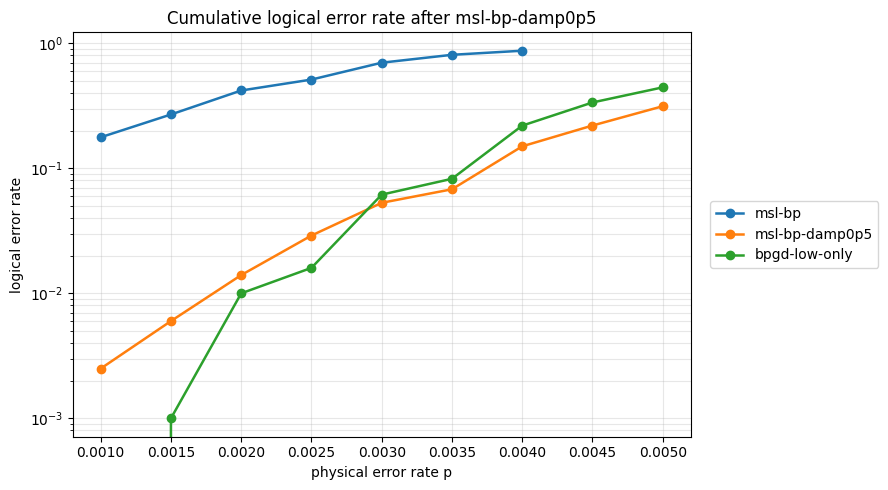

resume_csv = C:\Users\User\Documents\projects-git\relay_mother_folder\relay\examples\notebook_data\bicycle_bivariate_144_12_12_native_bpgd\bicycle_bivariate_144_12_12_native_bpgd_resume.csv
summary_csv = C:\Users\User\Documents\projects-git\relay_mother_folder\relay\examples\notebook_data\bicycle_bivariate_144_12_12_native_bpgd\bicycle_bivariate_144_12_12_native_bpgd_summary.csv
flat_summary_csv = C:\Users\User\Documents\projects-git\relay_mother_folder\relay\examples\notebook_data\bicycle_bivariate_144_12_12_native_bpgd\bicycle_bivariate_144_12_12_native_bpgd_flat_summary.csv


In [7]:
samples, summary_df = run_decoder(
    "msl-bp-damp0p5",
    plot_title="Cumulative logical error rate after msl-bp-damp0p5",
)


## Decoder 3: Native BPGD, Low Phase Only

In [ ]:
samples, summary_df = run_decoder(
    "bpgd-low-only",
    plot_title="Cumulative logical error rate after bpgd-low-only",
)


Starting 7 workers...
2 tasks left:
  workers       decoder eta shots_taken errors_seen json_metadata                                                                                                                                                                                                                                                                                                                                                                                                           
        3 bpgd-low-only   ?       10001           1 stim_path=C:\Users\User\Documents\projects-git\relay_mother_folder\relay\tests\testdata\bicycle_bivariate\circuit=bicycle_bivariate_144_12_12_memory_X,distance=12,rounds=12,error_rate=0.001,noise_model=uniform_circuit,basis=CX,A=x^3+y+y^2,B=y^3+x+x^2.stim,circuit=bicycle_bivariate_144_12_12_memory_X,distance=12,rounds=12,error_rate=0.001,noise_model=uniform_circuit,basis=CX,A=x^3+y+y^2,B=y^3+x+x^2,p=0.001
        4 bpgd-low-only   ?        1000   

## Decoder 4: Native BPGD With `initial_decimation_percentage = 0.98`

In [ ]:
samples, summary_df = run_decoder(
    "bpgd-high-init0p98",
    plot_title="Cumulative logical error rate after bpgd-high-init0p98",
)


Starting 7 workers...
5 tasks left:
  workers            decoder eta shots_taken errors_seen json_metadata                                                                                                                                                                                                                                                                                                                                                                                                           
        1 bpgd-high-init0p98   ?         887           0 stim_path=C:\Users\User\Documents\projects-git\relay_mother_folder\relay\tests\testdata\bicycle_bivariate\circuit=bicycle_bivariate_144_12_12_memory_X,distance=12,rounds=12,error_rate=0.001,noise_model=uniform_circuit,basis=CX,A=x^3+y+y^2,B=y^3+x+x^2.stim,circuit=bicycle_bivariate_144_12_12_memory_X,distance=12,rounds=12,error_rate=0.001,noise_model=uniform_circuit,basis=CX,A=x^3+y+y^2,B=y^3+x+x^2,p=0.001
        1 bpgd-high-init0p98   ?

## Decoder 5: Native BPGD With `initial_decimation_percentage = 0.9`

In [1]:
samples, summary_df = run_decoder(
    "bpgd-high-init0p9",
    plot_title="Cumulative logical error rate after bpgd-high-init0p9",
)


NameError: name 'run_decoder' is not defined